In [ ]:
'''
spark ok? (tentar dnv no fim)
algoritmo de agrupamento ok (qtd clusters*) ok
análise de cada cluster* ok
PCA aplicado
refinar análise (variância acumulada, exp pc, *resultado-salvar csv)
grafico 2d(separar clusters e ver tipos/ separar C1 e c2), grafico 3d)


Avaliar usar pokedex normal?

'''

In [ ]:
#from ucimlrepo import fetch_ucirepo 
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSessions
import os
import scipy.linalg as la
sns.set(style='whitegrid')
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

# Fuzzy C-Means (T1)

In [7]:
# 1° Passo - Montar Matriz W com sorteio
def matriz_w(X, clusters):
    W = []

    # Teremos que fazer o sorteio de 'clusters' valores 150 vezes (tamanho da iris)
    for linha in range(len(X)):
        # Gerando 'clusters' números aleatórios
        prob = [random.random() for _ in range(clusters)]

        # Transformando em entre 0 e 1 (percentual)
        prob_normalizados = [x / sum(prob) for x in prob]
        
        W.append(prob_normalizados)
        
    W = pd.DataFrame(W, columns=[f'C{i}' for i in range(1, clusters + 1)])
    return W 

# 2° Passo - Calcular o centróide dos cluster
def calcular_centroides(X, W):
    # Pegando a variável xi (todos valores do df)
    xi = X.values
    
    centroides = []
    
    for col in W.columns:
        pesos = W[col].values
        
        # Aplicando a fórmula
        numerador = np.sum(xi * pesos[:, None], axis=0)
        denominador = np.sum(pesos)
        
        centroides.append(numerador / denominador)
    
    return np.array(centroides)

# 3° Passo - Atualizar pesos

# Função de distância Euclidiana
def dist(a, b):
    return np.linalg.norm(a - b)

# Função para atualizar os pesos
def att_pesos(centroides, X, m):
    novos_pesos = []
    # Pra cada linha, atualizaremos os pesos
    for _, linha in X.iterrows():
        # Extraindo os valores da linha
        xi = linha.values
        
        # Calculando a distância de cada centroide para essa linha
        distancias = [dist(xi, c) for c in centroides]
        
        probabilidade_att = []
        for d in distancias:
            # Se a distância for 0, o peso é 1
            if np.any(d == 0):
                probabilidade_att.append(1.0)
            else:
                soma_razões = sum([(d / d_2)**(2/(m-1)) for d_2 in distancias])
                probabilidade_att.append(1 / soma_razões)
                
        novos_pesos.append(probabilidade_att)

    # Atualizando a matriz W com os novos pesos calculados
    W = pd.DataFrame(novos_pesos, columns=[f'C{i+1}' for i in range(len(centroides))])
    return W


# 4° Passo - Função para classificar amostras

# Função para dar uma classe a partir de uma diff comparada com o threshold
# O threshold funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade
def classificacao(W, threshold):
    classe = []
    
    for _, row in W.iterrows():
        valores = row.values
        
        # Ordena do maior pro menor para calcular a diff
        ordenados = np.sort(valores)[::-1]
        
        maior = ordenados[0]
        segundo = ordenados[1]
        
        diff = maior - segundo
        
        idx_max = valores.argmax()
        
        # Se a diff foi 'suficiente', classificamos
        if diff >= threshold:
            classe.append(f'cluster{idx_max}')
        else:
            classe.append('ruido')
    
    return np.array(classe)

# 5° Passo - Função final (mesclando tudo)

# Teremos um número máximo de iterações, mas ele poderá parar antes conforme o critério de parada pré-determinado  <----------------------
def fuzzy_c_means(X, clusters, threshold, m, max_iter=100):
    # Normalizando os valores de X usando min max
    scaler = MinMaxScaler()
    
    # Normalizando e voltando pra df
    X_norm = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    centroides = []
    
    # Criando a matriz W
    W = matriz_w(X_norm, clusters)
    
    # Looping até atingir o critério de parada ou o máximo de iterações fornecido
    for i in range(max_iter):
        centroide_atual = calcular_centroides(X_norm, W)
        W = att_pesos(centroide_atual, X_norm, m)
        centroides.append(centroide_atual)

        # Critério de parada: se a diferença entre os centróides atuais e os anteriores for menor que 10^-3 e i != 0 (não tem valor para comparar na 1° iteração), então paramos
        if (i != 0) and (np.max(np.abs(np.array(centroides[-1]) - np.array(centroides[-2]))) < 1e-3):
            print(f'    Critério de parada atingido, com {i} iterações')
            break
        
    # Classificaremos através de um threshold que funcionará como um valor mínimo da diferença entre os clusters com maior probabilidade, os que não passarem receberão cluster 'ruido'
    y = classificacao(W, threshold)
    
    # Calcularemos também o Silhouette como métrica de avaliação
    # Primeiro é preciso tirar as classes ruído
    X_sem_ruido = X_norm[y != 'ruido']
    W_sem_ruido = W[y != 'ruido']
    
    # Verificar número de clusters válidos
    labels = W_sem_ruido.values.argmax(axis=1)
    labels_unicos = np.unique(labels)

    # Se não tiver classificado ninguém ou tiver apenas um cluster, silhouette é -1, caso contrário aplica o silhouette de fato
    if len(X_sem_ruido) == 0 or len(labels_unicos) < 2:
        silhouette = -1
    else: 
        silhouette = silhouette_score(X_sem_ruido, labels)
    
    return np.array(centroides), W, y, silhouette

# Processamento Dados Brutos

In [ ]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
'''spark = SparkSession.builder.appName("Pokedex").getOrCreate()

# Leitura
df = spark.read.csv("pokedex_bruta.csv", header=True, inferSchema=True)

# Drop
df = df.drop("Image")

# Rename
df = (
    df.withColumnRenamed("Index", "num_pokedex")
      .withColumnRenamed("Name", "name")
      .withColumnRenamed("Type 1", "type_1")
      .withColumnRenamed("Type 2", "type_2")
      .withColumnRenamed("Total", "total")
      .withColumnRenamed("HP", "hp")
      .withColumnRenamed("Attack", "attack")
      .withColumnRenamed("Defense", "defense")
      .withColumnRenamed("SP. Atk.", "sp_atk")
      .withColumnRenamed("SP. Def", "sp_def")
      .withColumnRenamed("Speed", "speed")
)
# Dropando as variações por regiões Alola, Gallar, Hisui e forma Mega
df = df.dropDuplicates(["num_pokedex"])'''

Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: java.lang.NoClassDefFoundError: Could not initialize class org.apache.spark.unsafe.array.ByteArrayMethods
	at org.apache.spark.memory.MemoryManager.defaultPageSizeBytes$lzycompute(MemoryManager.scala:261)
	at org.apache.spark.memory.MemoryManager.defaultPageSizeBytes(MemoryManager.scala:251)
	at org.apache.spark.memory.MemoryManager.$anonfun$pageSizeBytes$1(MemoryManager.scala:271)
	at scala.runtime.java8.JFunction0$mcJ$sp.apply(JFunction0$mcJ$sp.scala:17)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.memory.MemoryManager.<init>(MemoryManager.scala:271)
	at org.apache.spark.memory.UnifiedMemoryManager.<init>(UnifiedMemoryManager.scala:67)
	at org.apache.spark.memory.UnifiedMemoryManager$.apply(UnifiedMemoryManager.scala:456)
	at org.apache.spark.SparkEnv.initializeMemoryManager(SparkEnv.scala:232)
	at org.apache.spark.SparkContext.<init>(SparkContext.scala:597

In [17]:
#df.show()

In [ ]:
# https://www.kaggle.com/datasets/christofferms/pokemon-with-stats-and-image?resource=download
'''df = pd.read_csv('pokedex_bruta.csv')

# Dropando colunas que não serão utilizadas
df = df.drop(['Image'], axis=1)

df = df.rename(columns = {'Index':'num_pokedex', 'Name':'name', 'Type 1':'type_1', 'Type 2':'type_2', 'Total':'total', 'HP':'hp', 'Attack':'attack',
       'Defense':'defense', 'SP. Atk.':'sp_atk', 'SP. Def':'sp_def', 'Speed':'speed'})

df.to_csv('pokedex.csv', index=False)
# Type 1 e 2 --> 18'''

In [ ]:
# Fazendo a versão sem as variações por regiões Alola, Gallar, Hisui e forma Mega
'''df = pd.read_csv('pokedex.csv')
df = df.drop_duplicates(subset=['num_pokedex'])
df.to_csv('pokedex_filtrada.csv', index=False)'''

# Algoritmo de Agrupamento

In [20]:
'''df = pd.read_csv('pokedex_filtrada.csv')
df.columns'''

"df = pd.read_csv('pokedex_filtrada.csv')\ndf.columns"

In [18]:
# Usaremos o Fuzzy C-Means aplicado no T1
# Com pandas
df = pd.read_csv('pokedex_filtrada.csv')
X = df[['total','hp', 'attack','defense', 'sp_atk', 'sp_def', 'speed']]

# Com Spark
'''X = df.select('total', 'hp', 'attack','defense', 'sp_atk','sp_def', 'speed')

# Convertendo X para pandas pq assim a função funcionará
X = X.toPandas()'''

# Definindo os parâmetros
threshold = 0.65
qtd_cluster = 4
max_iter = 200
coefs_silhouette = []

# Variaremos o m de 1.1 a 3 de 0.1 em 0.1 para determinal qual a melhor opção através do coef silhouette e quantidade de ruídos
ms = np.arange(1.1, 3.1, 0.1).round(1)

# Variaremos o m conforme a lista
for m in ms:
    cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, m, max_iter)
    
    # Adicionando a classificação a matriz W
    W['Class'] = y
    
    # Salvado algumas variáveis para avaliação
    n = len(W)
    ruido = len(W[W['Class'] == 'ruido'])
    prop_ruido = ruido / n

    # Ponderando a quantidade de ruído junto ao coeficiente de silhouette
    score = silhouette * (1 - prop_ruido)
    coefs_silhouette.append([m, ruido, silhouette, score]) 

    print(f"        m = {m} | Ruídos = {ruido} | Silhouette = {silhouette:.4f} | Score: {score:.4f}")

# Depois de rodar todos, precisamos bater o martelo para o melhor, nesse caso usando o coeficiente silhouette combinado com o ruído (score)
melhor = max(coefs_silhouette, key=lambda x: x[3])
melhor_m = melhor[0]
melhor_ruido = melhor[1]
melhor_silhouette = melhor[2]
melhor_score = melhor[3]

# Salvando as variáveis finais
print(f'\n\nDito isso, m = {melhor_m} apresentou o melhor coeficiente silhouette combinado com o ruído ({melhor_score:.4f})')

# Aplicando o modelo final com os melhores hiperparâmetros
cent, W, y, silhouette = fuzzy_c_means(X, qtd_cluster, threshold, melhor_m, max_iter)

    Critério de parada atingido, com 18 iterações
        m = 1.1 | Ruídos = 101 | Silhouette = 0.2788 | Score: 0.2513
    Critério de parada atingido, com 35 iterações
        m = 1.2 | Ruídos = 196 | Silhouette = 0.3075 | Score: 0.2487
    Critério de parada atingido, com 18 iterações
        m = 1.3 | Ruídos = 309 | Silhouette = 0.3392 | Score: 0.2369
    Critério de parada atingido, com 26 iterações
        m = 1.4 | Ruídos = 439 | Silhouette = 0.3632 | Score: 0.2076
    Critério de parada atingido, com 31 iterações
        m = 1.5 | Ruídos = 653 | Silhouette = 0.3335 | Score: 0.1210
    Critério de parada atingido, com 26 iterações
        m = 1.6 | Ruídos = 735 | Silhouette = -1.0000 | Score: -0.2829
    Critério de parada atingido, com 39 iterações
        m = 1.7 | Ruídos = 766 | Silhouette = -1.0000 | Score: -0.2527
    Critério de parada atingido, com 40 iterações
        m = 1.8 | Ruídos = 843 | Silhouette = -1.0000 | Score: -0.1776
    Critério de parada atingido, com 2 ite

# Visualização dos Clusters

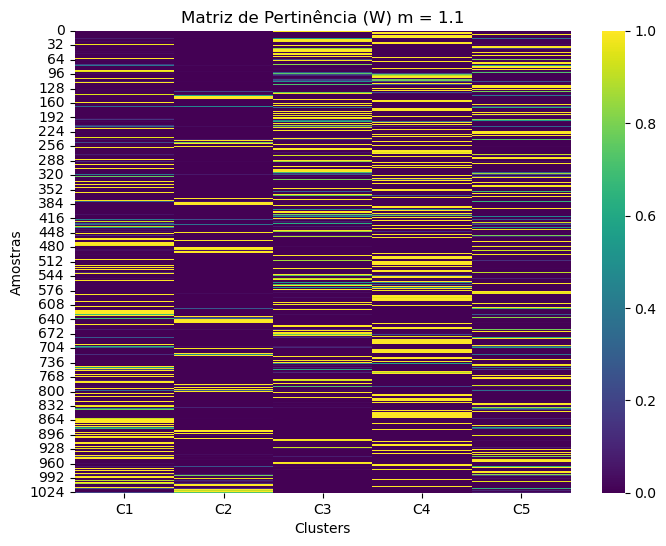

In [24]:
# Mostrando a pertinência através de um heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(W, cmap='viridis')

plt.title(f'Matriz de Pertinência (W) m = {melhor_m}')
plt.xlabel('Clusters')
plt.ylabel('Amostras')

plt.show()

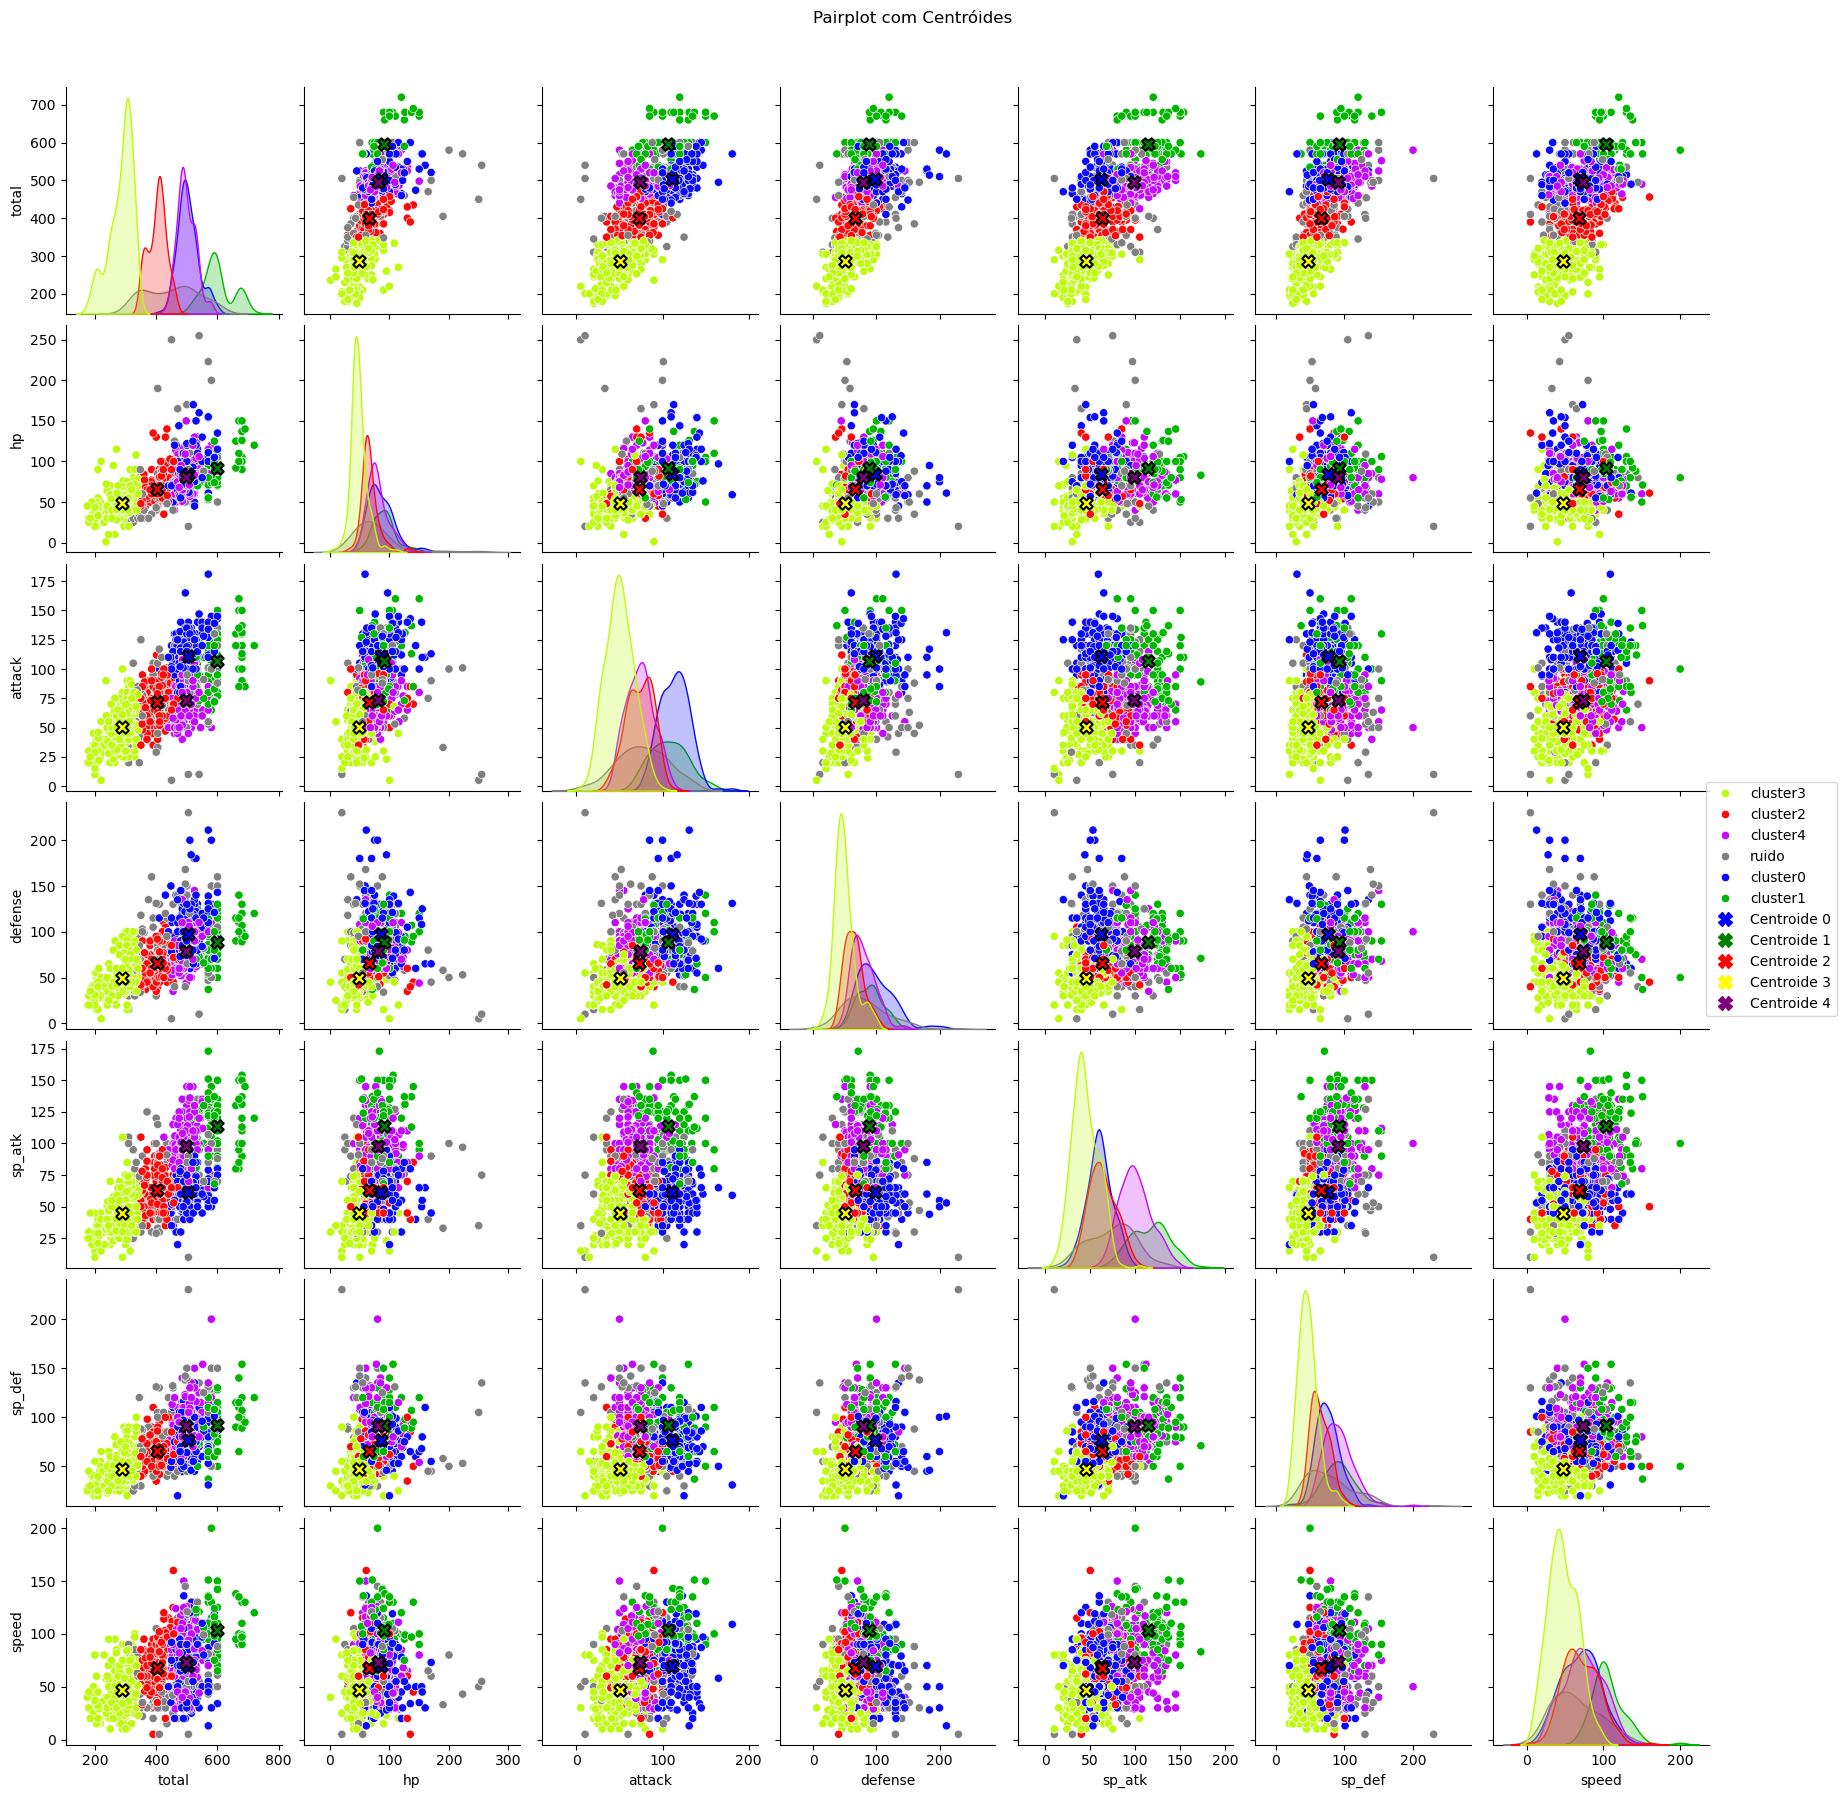

In [25]:
# Mostrando a separação de clusters, centroides e ruidos (zona de confusão)
df_plot = X.copy()
df_plot['classe'] = y

# Setando uma paleta de cores manualmente
palette = {
    'cluster0': "#0B0BFA",
    'cluster1': "#01B601",
    'cluster2': '#FA0B0B',
    'cluster3': "#BEFA0B",
    'cluster4': "#C20BFA",
    'ruido': 'gray'
}

g = sns.pairplot(df_plot, hue='classe', palette=palette, diag_kind='kde')

g.fig.suptitle("Pairplot com Centróides", y=1.03)

# Recuperando o scaler para inverter a normalização dos centroides
scaler = MinMaxScaler()
scaler.fit_transform(X)

centroides = scaler.inverse_transform(cent[-1])

cores_centroides = ['blue', 'green', 'red', 'yellow', 'purple']

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if i == j:
            continue
        
        for k, c in enumerate(centroides):
            ax.scatter(
                c[j], c[i],
                c=cores_centroides[k],
                marker='X',
                s=80,
                edgecolors='black',
                linewidths=1.5
            )

handles = g._legend.legend_handles
labels = [t.get_text() for t in g._legend.texts]

for i, cor in enumerate(cores_centroides):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='X',
            color='w',
            markerfacecolor=cor,
            markeredgecolor=cor,
            markersize=10,
            label=f'Centroide {i}'
        )
    )
    labels.append(f'Centroide {i}')

g._legend.remove()
g.fig.legend(handles=handles, labels=labels, loc='center right', ncol=1)

plt.show()

# Análise dos Clusters

In [24]:
df_final = X.copy()
df_final['name'] = df['name']
df_final['classe'] = y
df_final.to_csv('pokedex_fuzzy.csv', index=False)
colunas = ['total', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed']

# Média por cluster
df_cluster = (
    df_final
    .groupby('classe')[colunas]
    .mean()
    .round(2)
    .reset_index()
)

df_cluster

,classe,total,hp,attack,defense,sp_atk,sp_def,speed
0,cluster0,564.54,86.11,92.62,83.74,114.90,93.12,94.05
1,cluster1,434.97,71.77,70.64,70.02,76.35,75.94,70.24
2,cluster2,294.02,48.88,52.98,50.14,45.87,47.24,48.90
3,cluster3,504.00,85.79,114.02,97.89,61.70,75.49,69.12
4,ruido,483.23,82.15,80.16,86.72,75.97,86.28,71.96


In [ ]:
# Cluster 0 - 343 pokemons
# sp_atk, sp_def, hp, speed
# (Pika das galaxias)
# Composto por pokemons extremamentes fortes como 3° forma fortes, pseudo-lendários, lendários e míticos.


# Cluster 1 - 217 pokemons
# Equilibrados com atributos ~70
# Composto em geral por pokemons de 2° forma e pokemons que só tem 2 formas (ou pelo menos foram conforme lançamento).


# Cluster 2 - 178 pokemons
# -todos status --> Mais fracos/forma 1
# Composto em geral por pokemons de 1° forma e comuns


# Cluster 3 - 96 pokemons
# Pokemons com maior Atk
# Composto em geral por pokemons de 3° forma e 2° formas fortes


# Ruído - 191 pokemons
# Em geral estão na zona de confusão entre 2° e 3° forma e pseudo-lendários

# PCA

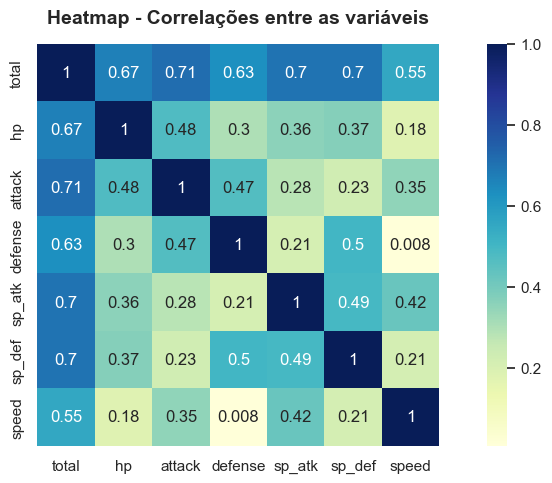

In [42]:
# Avaliando a correlação entre as vars 
plt.figure(figsize=(10,5))
plt.title('Heatmap - Correlações entre as variáveis', fontsize=14, pad=15, fontweight='bold')
ax=sns.heatmap(X.corr(),
               annot=True,
               cmap='YlGnBu',
               cbar_kws={"orientation":"vertical"}, )
ax.set_aspect("equal")
plt.tight_layout()

In [ ]:
# Aplicando o PCA
pca = PCA()
resultado_pca=pca.fit_transform(scale(X.values))
resultado=pd.DataFrame({'cp1':resultado_pca[:,0],'cp2':resultado_pca[:,1],'cp3':resultado_pca[:,2], 'cp4':resultado_pca[:,3], 'cp5':resultado_pca[:,4], 'cp6':resultado_pca[:,5], 'cp7':resultado_pca[:,6]})

In [44]:
X.columns

Index(['total', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed'], dtype='object')

In [46]:
# Avaliando os componentes principais
for i, cp in enumerate(pca.components_.round(2)):
    if i == 3: break
    print(f'CP{i+1} = {cp[0]}*total +    {cp[1]}*hp +    {cp[2]}*attack +   {cp[3]}*defense +    {cp[4]}*sp_atk +   {cp[5]}*sp_def +    {cp[6]}*speed')
    

CP1 = 0.52*total +    0.36*hp +    0.37*attack +   0.33*defense +    0.37*sp_atk +   0.37*sp_def +    0.27*speed
CP2 = 0.03*total +    -0.11*hp +    -0.08*attack +   -0.59*defense +    0.35*sp_atk +   -0.17*sp_def +    0.69*speed
CP3 = 0.01*total +    0.26*hp +    0.64*attack +   -0.03*defense +    -0.4*sp_atk +   -0.59*sp_def +    0.15*speed


In [47]:
# variância explicada dos CPs
pca.explained_variance_ratio_

array([5.20348239e-01, 1.57939764e-01, 1.26023060e-01, 9.60305088e-02,
       6.06208424e-02, 3.90375852e-02, 2.65010960e-17])

In [48]:
#variância explicada acumulada
np.cumsum(np.round(pca.explained_variance_ratio_,decimals=4)*100)

array([52.03, 67.82, 80.42, 90.02, 96.08, 99.98, 99.98])

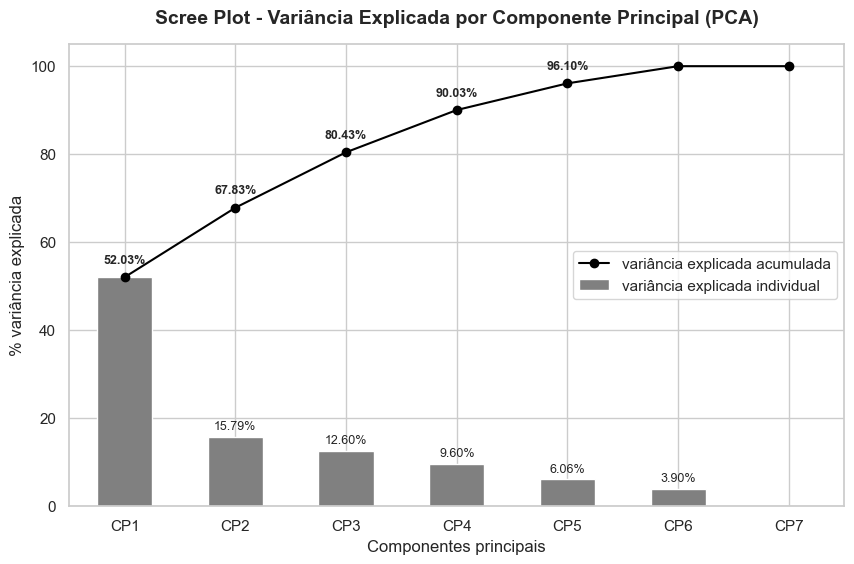

In [ ]:
# Avaliando também com o gráfico da variância acumulada e individual
# variâncias acumuladas
tot = sum(pca.explained_variance_)
var_exp = [(i / tot)*100 for i in sorted(pca.explained_variance_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
# número de CPs gerados (k = p)
cp =['CP'+str(i+1) for i in range(len(pca.components_))]
# dataframe com as variâncias acumuladas para criar o scree plot
df_plot = pd.DataFrame({'cp': cp, 'var_exp': var_exp, 'cum_var_exp': cum_var_exp})
# scree plot com %
fig, ax = plt.subplots(figsize=(10, 6)) # Ajuste no tamanho para acomodar os novos textos
df_plot.plot.bar('cp', 'var_exp', color='gray', ax=ax, legend=False)
df_plot.plot.line('cp', 'cum_var_exp', color='black', marker='o', ax=ax) # Adicionado marcador de ponto na linha

# Adiciona o valor percentual acima de cada barra (individual)
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 1 and i > 0: 
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
        
# Adiciona o valor percentual acima de cada ponto da linha (acumulada)
for i, val in enumerate(df_plot['cum_var_exp']):
    if val < 99.9 or i == 7:
        ax.annotate(f'{val:.2f}%',
                    xy=(i, val),
                    xytext=(0, 8),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Scree Plot - Variância Explicada por Componente Principal (PCA)', fontsize=14, pad=15, fontweight='bold')
plt.legend(labels=['variância explicada acumulada', 'variância explicada individual'], loc='center right')
plt.ylabel('% variância explicada')
plt.xlabel('Componentes principais');

In [ ]:
# Fazer uma análise que nem essa de baixo pra explicarmos os gráficos


# CP1
# Top impactantes: Jardas, Compl, TD, Tent, Percent e PorTent (Todo acima de 0.30) | Depois: 0.28

# CP2
# Top impactantes: PerInt e Int (acima de 0.61) | Depois: -0.25

# CP3
# Top impactantes: Tent, Time_PIT, -PorTent, -PerTD, -Time_SD e Compl  (Todos acima de |0.3|)  | Depois: -0.24

In [54]:
resultado

,cp1,cp2,cp3,cp4,cp5,cp6,cp7
0,-1.818234,0.073366,-0.773462,0.071673,0.247149,0.307121,4.480938e-17
1,-0.352010,0.152598,-0.810617,0.075908,0.129840,0.217507,-1.579865e-16
2,1.669972,0.224993,-0.803887,0.044213,-0.001560,0.122016,-2.021621e-16
3,-2.053171,0.729066,-0.262278,-0.291219,0.153132,0.075379,-1.945484e-16
4,-0.430631,0.835362,-0.349152,-0.151951,0.109512,-0.105881,-4.632978e-16
...,...,...,...,...,...,...,...
1020,2.810833,0.304263,-0.839676,1.577484,0.633614,-0.903710,-1.099545e-15
1021,2.682327,0.782059,0.592091,-0.616452,-1.338404,0.582013,2.327229e-16
1022,2.730473,0.522206,-1.311089,0.016058,-0.006869,-0.575870,-1.099545e-15
1023,0.431371,-0.626471,-0.381238,0.509984,-0.525761,-0.304699,-8.278964e-17


In [ ]:
componentes = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)
componentes

In [20]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import plotly.express as px

# ===============================
# Padronização
# ===============================

std = StandardScaler()
X_std = std.fit_transform(X)

# ===============================
# PCA com 3 componentes
# ===============================

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_std)

# ===============================
# DataFrame para visualização
# ===============================

df_plot = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'PCA3': X_pca[:, 2],
    'Cluster': y.astype(str),

    # Informações adicionais
    'Pokedex': df['num_pokedex'],
    'Nome': df['name'],
    'Tipo 1': df['type_1'],
    'Tipo 2': df['type_2'],
    'Total': df['total'],
    'HP': df['hp'],
    'Attack': df['attack'],
    'Defense': df['defense'],
    'Sp. Atk': df['sp_atk'],
    'Sp. Def': df['sp_def'],
    'Speed': df['speed']
})

# ===============================
# Plot 3D interativo
# ===============================

fig = px.scatter_3d(
    df_plot,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    hover_data={
        'Pokedex': True,
        'Nome': True,
        'Tipo 1': True,
        'Tipo 2': True,
        'Total': True,
        'HP': True,
        'Attack': True,
        'Defense': True,
        'Sp. Atk': True,
        'Sp. Def': True,
        'Speed': True,

        # Não mostrar duplicado
        'PCA1': False,
        'PCA2': False,
        'PCA3': False
    },
    opacity=0.7,
    title='Fuzzy C-Means + PCA 3D',
    width=1100,
    height=800
)

# Ajustando tamanho dos pontos
fig.update_traces(marker=dict(size=5))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='Componente Principal 1',
        yaxis_title='Componente Principal 2',
        zaxis_title='Componente Principal 3'
    )
)

# ===============================
# Variância explicada
# ===============================

print('Variância explicada por componente:')
print(pca.explained_variance_ratio_)

print(f'\nVariância total explicada: {pca.explained_variance_ratio_.sum():.4f}')

# ===============================
# Exibindo gráfico
# ===============================

fig.show()

Variância explicada por componente:
[0.52034824 0.15793976 0.12602306]

Variância total explicada: 0.8043


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed